# Atomic polarization

2022.06.08  k.i.  
2024.12.05  k.i.   density matrix for J=J'

In [1]:
#from IPython.core.display import display, HTML
#display(HTML("<style>.container { width:100% !important; }</style>"))

%load_ext autoreload
%autoreload 2
import sys

sys.path.append("C:/home/Python/")
from lib.idl_wrapper import iplot
from spectra.spectra_src import Constants as Cst

sys.path.append("../")

import matplotlib.pyplot as plt   # module for plotting
from matplotlib.colors import LogNorm

plt.style.use("ggplot")

import numpy as np                # module for vectorized numeric calculation

from IPython.display import Math
#init_printing()   # hungup
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

from spectra_src.ImportAll import *
from spectra_src.Util.HelpUtil import help_
from spectra_src import Constants as Cst

#-----  enlarge width of cells  -----------------
np.get_printoptions()
np.set_printoptions(linewidth=100)


def symbol2str(h):  # symbol name -> character
  import inspect, re
  frame = inspect.getouterframes(inspect.currentframe())[1][0]
  arg_str = inspect.getframeinfo(frame).code_context[0]
  arg = re.search('\((.+?)\)', arg_str).group(1)
  return arg

In [2]:
import sympy.physics
import sympy.physics.wigner
from sympy import *
import sympy as sp

# sympy Kou special to overload sympy.physics.wigner._int_or_halfint,  2024.12.21
def _int_or_halfint(value):
    """return Python int unless value is half-int (then return float)"""
    """added numpy.int*/float* support"""

    from sympy.core.numbers import (Float, Rational)
    import numpy

    if isinstance(value, int) or isinstance(value, numpy.integer):
        return int(value)
    elif (type(value) is float) or isinstance(value, numpy.floating):
        if value.is_integer():
            return int(value)  # an int
        if (2*value).is_integer():
            return float(value)  # a float
    elif isinstance(value, Rational):
        if value.q == 2:
            return value.p/value.q  # a float
        elif value.q == 1:
            return value.p  # an int
    elif isinstance(value, Float):
        return _int_or_halfint(float(value))
    raise ValueError("expecting integer or half-integer, got %s" % value)


import sympy
sympy.physics.wigner._int_or_halfint = _int_or_halfint  # overload sympy.physics.wigner._int_or_halfint
del sympy


# Standard representation

### 基底ベクトルは角運動量の固有状態　　 $|JM\rangle, \qquad  -J \le M \le J$ 

===================================================================================
# まず、座標の回転

##### 座標系（或いはベクトル）の回転$D(\alpha,\beta, \gamma)$により、z系における$𝐽_𝑧=𝑁$の固有状態$|JN\rangle$ は z’系におけるは$𝐽_{𝑧’}=𝑁$ の固有状態 $|JN\rangle'=D|JN\rangle$ となる。
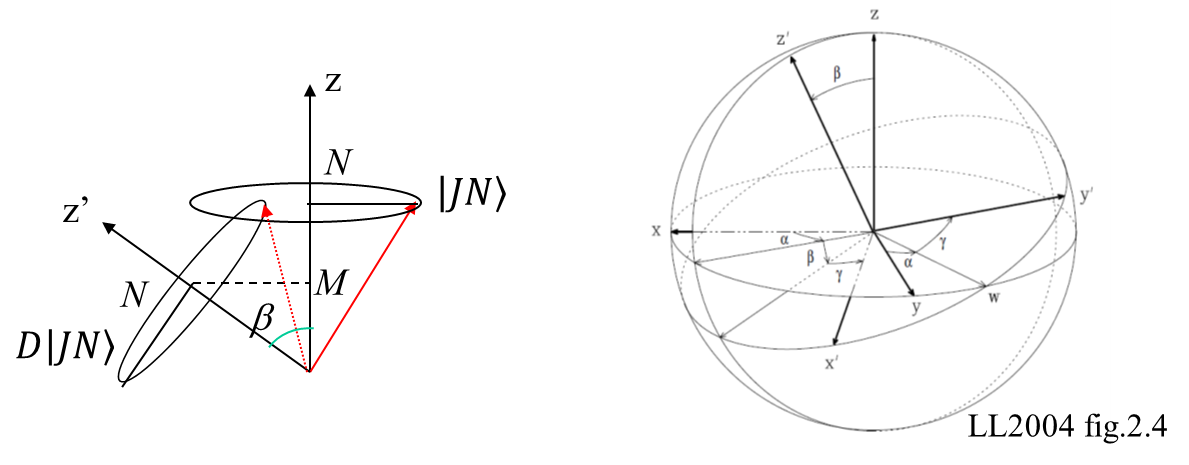
##### ここで、$-J < M,N < J、J$ は変わらない。量子化軸間$z,z'$の角度が$\beta$ である。
##### $D^J$の$z$系における要素:  $D^J_{MN} =\langle JM|D^J|JN\rangle= e^{-i(\alpha M + \gamma N)}d^J_{MN}(\beta)$　
##### $𝐷|𝐽𝑁⟩$　が$𝐽_𝑧=𝑀$ をもつ確率が　 $|𝐷^J_{𝑀𝑁}|^2$  
##### 𝑀,𝑁はあくまで元座標系(𝑥,𝑦,𝑧)に準拠した基底ベクトルの磁気量子数である。

## reduced rotation matrix
#### マトリクス     $d^J(\beta)  \quad の要素：   d^J_{MN}(\beta) = \langle M \mid d^J(\beta) \mid N\rangle$   

![スクリーンショット 2025-11-15 20.11.50.jpeg](<attachment:スクリーンショット 2025-11-15 20.11.50.jpeg>)

#### * the sum runs over all the t values which lead to non-negative factorials. [LL_2004  eq.(2.69)]

##### $D^J_{MN}$ は座標の基底ベクトルが cartesian $[\bf{x,y,z}]$ でもspherical $[\bf{e_-,e_0,e_+}]$ でも同じあろう。
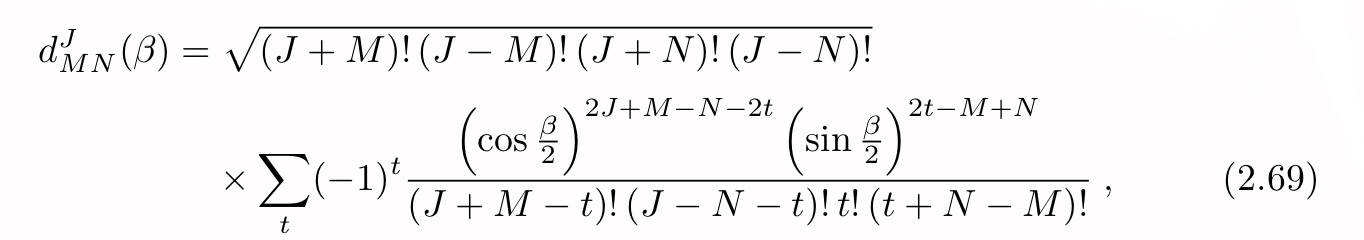

In [3]:
#------------------------------------------------------------
# reduced rotation matrix element
def dJMN1(J,M,N,bet):
    t = sp.symbols('t')

    # Wigner’s formula   from Landi Ch.2
    a = sp.sqrt(sp.factorial(J+M)*sp.factorial(J-M)*sp.factorial(J+N)*sp.factorial(J-N))
    b = (cos(bet/2))**(2*J+M-N-2*t)*(sin(bet/2))**(2*t-M+N)
    c = sp.factorial(J+M-t)*sp.factorial(J-N-t)*sp.factorial(t)*sp.factorial(t+N-M)
    if M-N > 0:
        t1 = 0
    else:
        t1 = M-N
    if J+M > J-N:
        t2 = J-N
    else:
        t2 = J+M
    d = a * sp.summation((-1)**t *b/c, (t,t1,t2))

    return  sp.trigsimp(d)

#------------------------------------------------------------
def RotationMatrix(J,bet):
    M, N = sp.symbols('M N')

    dmat = sp.zeros(2*J+1,2*J+1)

    for N in np.arange(-J,J+1):
        for M in np.arange(-J,J+1):
            #print(M,N)
            dmat[N+J,M+J] = dJMN1(J,M,N,bet)

    return dmat
    

In [4]:
# reduced rotation matrix
J, bet = sp.symbols('J beta')

J = sp.Rational(3,2)
#J = 2
drot = RotationMatrix(J,bet)
display(Math(r'd^{%s}'%J +r'_{M,N}='),drot)


<IPython.core.display.Math object>

Matrix([
[                    cos(beta/2)**3, -sqrt(3)*sin(beta/2)*cos(beta/2)**2, sqrt(3)*sin(beta/2)**2*cos(beta/2),                     -sin(beta/2)**3],
[sqrt(3)*sin(beta/2)*cos(beta/2)**2,   cos(beta/2)/4 + 3*cos(3*beta/2)/4, (3*sin(beta/2)**2 - 2)*sin(beta/2),  sqrt(3)*sin(beta/2)**2*cos(beta/2)],
[sqrt(3)*sin(beta/2)**2*cos(beta/2),  (2 - 3*sin(beta/2)**2)*sin(beta/2),  cos(beta/2)/4 + 3*cos(3*beta/2)/4, -sqrt(3)*sin(beta/2)*cos(beta/2)**2],
[                    sin(beta/2)**3,  sqrt(3)*sin(beta/2)**2*cos(beta/2), sqrt(3)*sin(beta/2)*cos(beta/2)**2,                      cos(beta/2)**3]])

drotn (181, 4, 4)


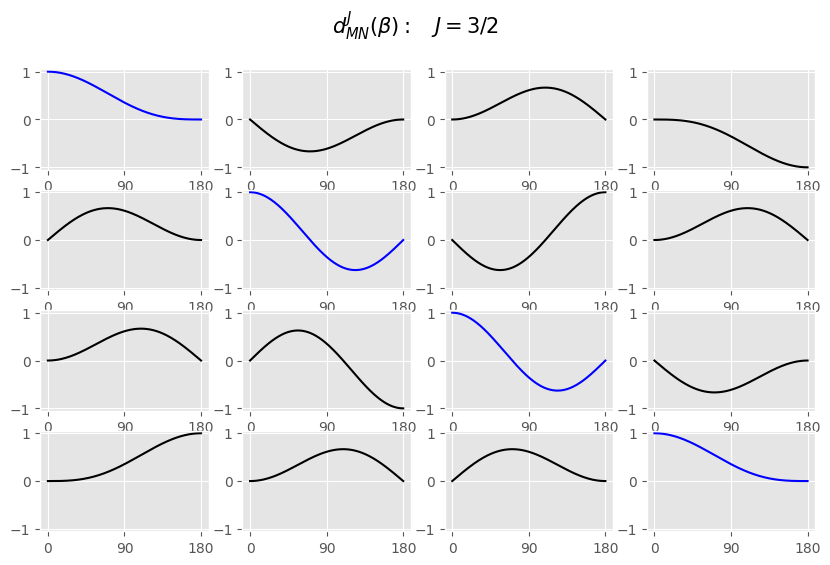

In [5]:
import matplotlib.pyplot as plt   # module for plotting

beta = np.linspace(0,180,181)
nb = beta.size
drotn = np.zeros([nb,2*J+1,2*J+1])
for i in range(nb):
    b1 = beta[i]/180.*np.pi
    #print(b1)
    drotn[i,:,:] = sp.matrix2numpy(drot.subs(([(bet,b1)])))
    
print('drotn',drotn.shape)
nJ = 2*J+1
fig, axs = plt.subplots(nJ,nJ, figsize=(10,6))
for i in range(0,nJ):
    for j in range(0,nJ):
        ax = axs[i,j]
        if i==j:
            color='blue'
        else:
            color='black'
        ax.plot(beta,drotn[:,i,j],color=color)
        ax.set_ylim(-1.05,1.05)
        ax.set_xticks([0,90,180]) 
        
plt.suptitle(r"$d^J_{MN}(\beta): \quad   J={%s}$"%(J),fontsize=15)
plt.show()

### ===========================================================================================
## spherical tensor operator of rank K


##### ２つの角運動量 𝐽,𝐽′ の混合を考え、  
###### $(2J+1)\times (2J'+1) = \sum_{K=|J-J'|}^{J+J'}(2K+1)$ 個の component 、$T^K_Q(JJ')$　(=Matrix)、を以下により定義

###### 
$$ T^K_Q(JJ') = \sum_{M,M'}(-1)^{J'-M'}\langle JJ'M-M'\mid KQ\rangle \mid JM\rangle\langle J'M'\mid  \\
= \sum_{M,M'}(-1)^{J-M}\sqrt{2K+1} 
\begin{pmatrix}
J & J' & K \\
M & -M' & -Q \\
\end{pmatrix}
|JM\rangle\langle J'M'| \\
|J-J'| \le K \le J+J',\qquad  Q = -K,,,,K  \\
\\
|JM\rangle\langle J'M'| =
\begin{pmatrix}
0 \\
1_M \\
0 \\
\end{pmatrix}
\begin{pmatrix}
0 & \cdots & 1_{M'} & 0 \\
\end{pmatrix}
=
\begin{pmatrix}
0 & \cdots & 0 & 0 & 0 \\
0 & \cdots & \vdots & 1_{MM'} & 0 \\
0 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
\qquad (2J+1)\times(2J'+1) \\
$$

$T^K_Q(J,J')$ も同じ形をしたmatrix. 要素を　$T^K_Q(J,J')_{M,M'}$ と書く.  
3-j symbol の規格化 
$\sum_{MM'}(2K+1) 
\begin{pmatrix}
J & J' & K \\
M & -M' & -Q \\
\end{pmatrix}
^2 = 1 $ より、$T^K_Q(J,J')_{M,M'}$ 各要素の2乗和は1



### 密度演算子の multipole moment (=element) 定義
##### 
$$ \rho^K_Q(J,J')=\sum_{M,M'}{(-1)^{J'-M'}} \langle JJ'M-M' \mid KQ\rangle  \rho(JM,J'M') \\
= \sum_{M,M'}(-1)^{J-M}\sqrt{2K+1} 
\begin{pmatrix}
J & J' & K \\
M & -M' & -Q \\
\end{pmatrix}
\rho(JM,J'M') \\
= \sum_{M,M'}^{} T^K_Q(J,J')_{MM'}\rho(JM,J'M') \quad (\bf{Hadamard \ product; elementwise) }\\
$$

・密度行列はエルミート（正方）であり、$J$と$J'$、或いは $JM$ と $J'M'$ は同じサイズを張る.  
・$J \ne J'$のとき、$ \rho^K_Q(J,J')$ は、密演行列非対角部の1区画である $(2J+1)\times(2J'+1)$ の行列に対応  
・$K=0$ : monopole,    $K=1$ : dipole,    $K=2$ : quadropole  

#### $$\rho(J,J') = \sum_{K,Q}\rho^K_Q(J,J') T^K_Q(J,J') $$


### Spherical tensors  $T^K_Q(J,J')$

In [5]:
def romat_symbolic(J1,J2): # ro(J,J') 行列シンボル
    
    n1 = 2*J1+1
    n2 = 2*J2+1
    romat_mm = sp.MatrixSymbol('rho',n1,n2)  #  
    romat_ij = sp.zeros(n1,n2)
    M1s = [-J1+i for i in sp.Range(n1)]
    M2s = [-J2+i for i in sp.Range(n2)]
    for m1 in M1s:
        for m2 in M2s:
            romat_ij[m1+J1,m2+J2] = romat_mm[m1,m2]

    return(romat_ij)

J1=1 ; J2=2
mat = romat_symbolic(J1,J2)
display(mat)

Matrix([
[rho[-1, -2], rho[-1, -1], rho[-1, 0], rho[-1, 1], rho[-1, 2]],
[ rho[0, -2],  rho[0, -1],  rho[0, 0],  rho[0, 1],  rho[0, 2]],
[ rho[1, -2],  rho[1, -1],  rho[1, 0],  rho[1, 1],  rho[1, 2]]])

In [7]:
# make spherical tensor Tkq(J1,J2) in standard representation 
from sympy.physics.wigner import wigner_3j
import dataclasses
from dataclasses import dataclass, field

@dataclass   
class SphericalTensors:  # Tkq class for (J1,J2)

    J1: int | float                     # input argument
    J2: int | float                     # input argument
    M1s: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  
    M2s: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  
    Ks: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  
    Qs: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  
    Tkq: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1,1), init=False)  
    #Tkq: list = field(default_factory=lambda: sp.zeros(1,1), init=False)  # こっちもOk
    fct: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False) 
    sym: str = field(default_factory=lambda: '', init=False)
    rosym: str = field(default_factory=lambda: '', init=False)
    moment: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  

    def __post_init__(self):
        self.J1 = J1
        self.J2 = J2
        n1 = 2*J1+1
        n2 = 2*J2+1
        M1s = []  ;  M1s += [-J1+i for i in sp.Range(2*J1+1)]
        M2s = []  ;  M2s += [-J2+i for i in sp.Range(2*J2+1)]
        self.M1s = M1s
        self.M2s = M2s
        nK = J1+J2 - Abs(J2-J1) +1
        KK = [Abs(J1-J2)+i for i in sp.Range(nK)]
        Ks = []
        Qs = []
        for K in KK:
            Ks += [K]*(2*K+1)
            Qs += [-K+i for i in sp.Range(2*K+1)]
        self.Ks = Ks
        self.Qs = Qs
        nn = len(Ks)
        Tkq = []
        fct = []
        sym = []
        for l in range(nn):
            K = Ks[l]  ; Q = Qs[l]
            Tkq1 = sp.zeros(n1,n2)  # need to create everytime
            for i in range(n1):
                M1 = -J1+i
                for j in range(n2):
                    M2 = -J2+j
                    Tkq1[i,j] = (-1)**(J1-M1) *sp.sqrt(2*K+1) * wigner_3j(J1, J2, K, M1, -M2, -Q)
            #display(Tkq1)
            abs_non_zero = [element for element in Tkq1.applyfunc(Abs) if element != 0]
            if len(abs_non_zero) == 0:
                fct1 = 0
            else:
                fct1 = min(abs_non_zero)
            sym1 = r'T^{%s}_{%s}' %(K,Q)
            
            Tkq.append(Tkq1)
            fct.append(fct1)
            sym.append(sym1)
        
        self.Tkq = Tkq
        self.fct = fct
        self.sym = sym
        
    def moment(self,romat):       # メソッド    Multipole moment of romat
        
        Ks = self.Ks
        Qs = self.Qs
        nn = len(Ks)
        rokq = []
        for i in range(nn):
            K = Ks[i]
            Q = Qs[i]
            roT = sp.matrix_multiply_elementwise(romat,m.Tkq[i])  # Hadamard product sum
            rokq.append(sum(roT))   # <-- multipole moment

        self.moment = rokq
        return self.moment
        
        
def msymbol(ch,K,Q):      # 文字記号
        
    sym = r'%s^{%s}_{%s}' %(ch,K,Q)
    return sym
    
#-----------------------------------------------------------------------        
J1 = sp.Rational(1,2) ; J2 = sp.Rational(1,2)
J1 = sp.Rational(1,1) ; J2 = sp.Rational(1,1)

m = SphericalTensors(J1,J2)
print('J1,J2 = ',J1,J2)
print('Ks =',m.Ks)
print('Qs =',m.Qs)
nn = len(m.Tkq)

romat = romat_symbolic(J1,J2)
rokq = m.moment(m,romat)

Ks = m.Ks ;  Qs = m.Qs
for i in range(nn):
    K = Ks[i]
    Q = Qs[i]
    if m.fct[i] == 1:
        cfct = ''
    else:
        cfct = latex(m.fct[i])
    rokq1 = sp.simplify(rokq[i]/m.fct[i])
    output = msymbol('T',K,Q) +f"= {cfct} {latex(m.Tkq[i]/m.fct[i])}" \
        +"\\qquad   "+msymbol('\\rho',K,Q)+f"=  {cfct} ({latex(rokq1)})" 
    #output = f"{latex(sp.factor(rokq[i]))}"
    display(Math(output))



J1,J2 =  1 1
Ks = [0, 1, 1, 1, 2, 2, 2, 2, 2]
Qs = [0, -1, 0, 1, -2, -1, 0, 1, 2]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### $\bf{\rho}\it{(J,J')}= \sum_{K=|J-J'|}^{J+J'} \sum_{Q =-K}^K \rho^K_Q\bf{T}\it{(J,J')}^K_Q \quad  の確認 $
 

In [8]:
# *******************************************************************************
# multipole moments (of density matrix)

J = 1
J1 = J2 = J
#J1 = sp.Rational(1,1) ; J2 = sp.Rational(0,1)


m = SphericalTensors(J1,J2)
Ks = m.Ks ; Qs = m.Qs

# multipole moment
romat = romat_symbolic(J1,J2)
rokq = m.moment(m,romat)

n1 = romat.shape[0]
n2 = romat.shape[1]

tmat = sp.zeros(n1,n2)
for K in range(max(Ks)+1):
    ii = np.where(np.array(Ks) == K)[0]
    nK = ii.size
    output = ''
    for i in ii:
        tmat += rokq[i] * m.Tkq[i]
        Tkq1 = sp.simplify(m.Tkq[i]/m.fct[i])
        if m.fct[i] == 1:
            cfct = ''
        else:
            cfct = latex(m.fct[i])
        output += r'\rho^{%s}_{%s}' %(Ks[i],Qs[i]) +f"{cfct} {latex(Tkq1)}+"
    display(Math(output))
    
display(Math('='+f"{latex(sp.simplify(tmat))}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Term  (L,S) の密度演算子

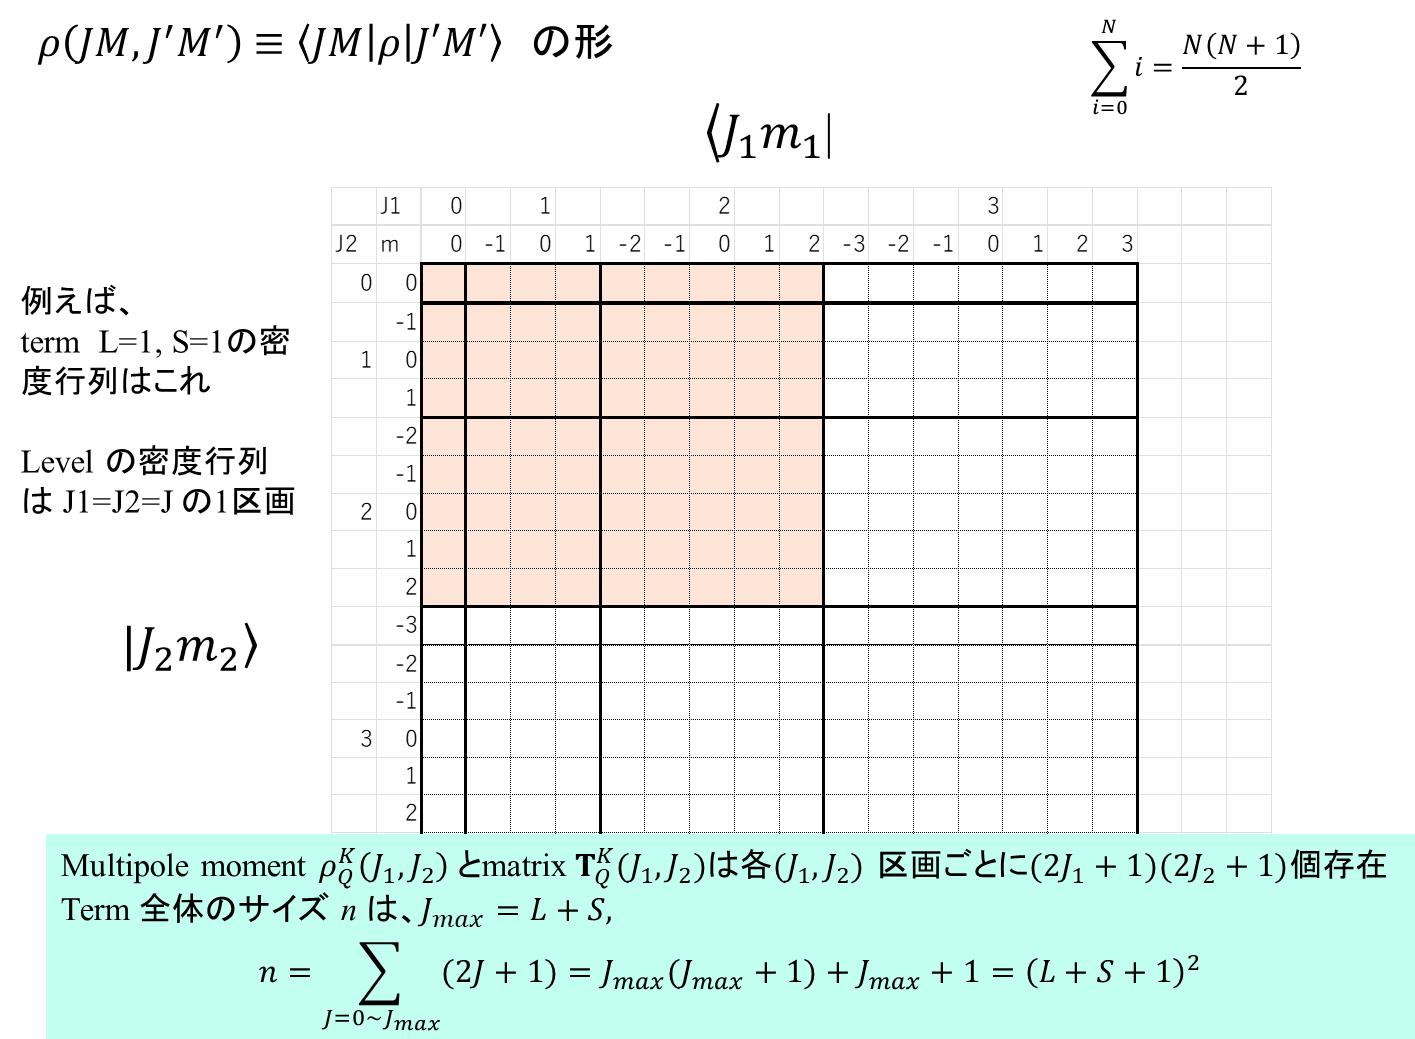

#### 全体を、$\rho = \sum_{K=|J-J'|}^{J+J'}\sum_{Q=-K}^{K}\rho^K_Q T^K_Q \quad $ と展開できるだろうか？


## Ortho He 5-terms model  (multi-term atom)
Asensio Ramos, Trujillo Bueno and Landi Degle Innocenti, 2008

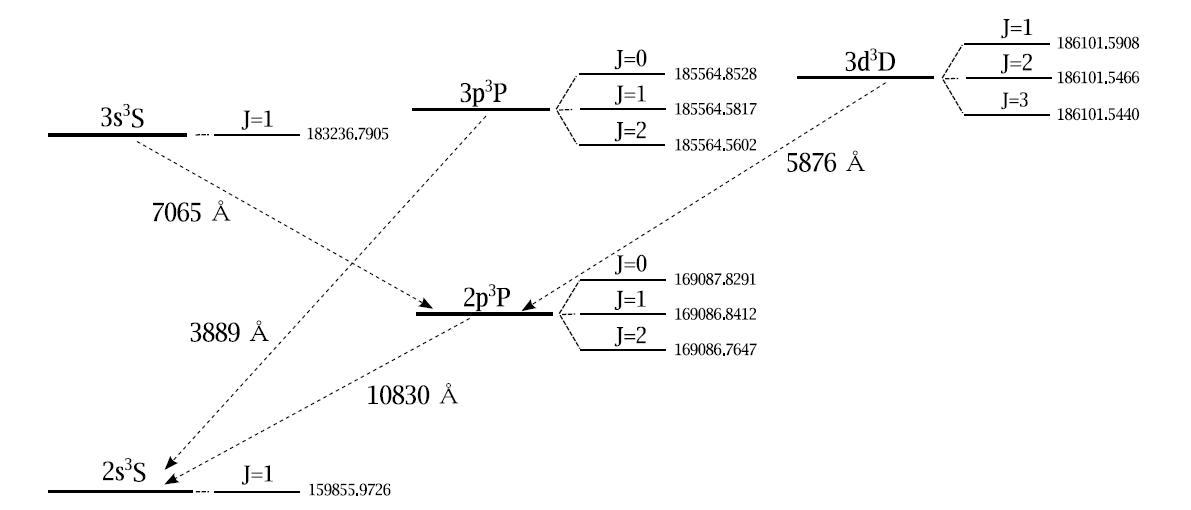



Term ごとのsubstates

$$
\begin{array}{ccc|cc|cc}
\hline
\rm{term}  &  L & S & J & M & & \rm{＃ \ of \ substates} \\
\hline
3d^3D & 2 & 1 & 1 & -1,0,1 & 3 \\
      &   &   & 2 &  -2,-1,0,1,2 & 5 & 15\\
      &   &   & 3 &  -3,-2,-1,0,1,2,3 & 7 \\
\hline
3p^3P & 1 & 1 & 0 & 0 & 1 \\
      &   &   & 1 & -1,0,1 & 3  & 9 \\
      &   &   & 2 & -2,-1,0,1,2 & 5 \\
\hline
3s^3S & 0 & 1 & 1 & -1,0,1 & 3 & 3\\
\hline
2p^3P & 1 & 1 & 0 & 0  & 1 \\
      &   &   & 1 & -1,0,1 & 3 & 9 \\
      &   &   & 2 & -2,-1,0,1,2 & 5\\
\hline
2s^3S & 0 & 1 & 1 & -1,0,1 & 3 & 3\\
\hline
\end{array}
$$

### 異なるterm間の干渉はないとする。density matrix は各term ごとに1つ

L-S term のsubstate 数 $ =  (2L+1)(2S+1)$

density matrix の element 数 $= (2L+1)^2(2S+1)^2 \qquad$

Hermite（複素反対称）であるが、非対角成分が複素数なので独立自由度の数はこれと同じ  



In [9]:
# total number of density matrix element for 5-term ortho He model
S = 1
Ls = [0,1,0,1,2]
nn = 0
for L in Ls:
    nn += (2*L+1)**2 * (2*S+1)**2
    
nn

405

### Term LS の密度演算子 dataclass


In [10]:
# make matrix shape for term LS
def TermMatrixShape(L,S):

        ro = Symbol('rho')
        
        # if not satisfied as int_or_halfint then raise Error
        #L, S = [_int_or_halfint(v) for v in (L, S)]

        nJ = int(L + S - sp.Abs(L-S) +1)
        JJ = [sp.Abs(L-S)+i for i in sp.Range(nJ)]
        Js = []
        Ms = []
        for J in JJ:
            Js += [J]*(2*J+1)
            Ms += [-J+i for i in sp.Range(2*J+1)]
        n = len(Ms)
        romat = sp.zeros(n,n)
        #romat = sp.MatrixSymbol('rho',n,n)
        for i in range(n):
            for j in range(n):
                romat[i,j] = symbols(r"\rho_{%s%s\,%s%s}"%(Js[i],Ms[i],Js[j],Ms[j]))
        
        return(romat, Js, Ms)

    
#---------------------------------------------------------------
L, S = sp.symbols('L S')
L = 1 ;  S = 1
#S = sp.Rational(1,2)

romat, Js, Ms = TermMatrixShape(L,S)

print('L.S=',L,S)
print('J[:] =',Js)
print('M[:] =',Ms)
display(romat)


L.S= 1 1
J[:] = [0, 1, 1, 1, 2, 2, 2, 2, 2]
M[:] = [0, -1, 0, 1, -2, -1, 0, 1, 2]


Matrix([
[ \rho_{00,00},  \rho_{00,1-1},  \rho_{00,10},  \rho_{00,11},  \rho_{00,2-2},  \rho_{00,2-1},  \rho_{00,20},  \rho_{00,21},  \rho_{00,22}],
[\rho_{1-1,00}, \rho_{1-1,1-1}, \rho_{1-1,10}, \rho_{1-1,11}, \rho_{1-1,2-2}, \rho_{1-1,2-1}, \rho_{1-1,20}, \rho_{1-1,21}, \rho_{1-1,22}],
[ \rho_{10,00},  \rho_{10,1-1},  \rho_{10,10},  \rho_{10,11},  \rho_{10,2-2},  \rho_{10,2-1},  \rho_{10,20},  \rho_{10,21},  \rho_{10,22}],
[ \rho_{11,00},  \rho_{11,1-1},  \rho_{11,10},  \rho_{11,11},  \rho_{11,2-2},  \rho_{11,2-1},  \rho_{11,20},  \rho_{11,21},  \rho_{11,22}],
[\rho_{2-2,00}, \rho_{2-2,1-1}, \rho_{2-2,10}, \rho_{2-2,11}, \rho_{2-2,2-2}, \rho_{2-2,2-1}, \rho_{2-2,20}, \rho_{2-2,21}, \rho_{2-2,22}],
[\rho_{2-1,00}, \rho_{2-1,1-1}, \rho_{2-1,10}, \rho_{2-1,11}, \rho_{2-1,2-2}, \rho_{2-1,2-1}, \rho_{2-1,20}, \rho_{2-1,21}, \rho_{2-1,22}],
[ \rho_{20,00},  \rho_{20,1-1},  \rho_{20,10},  \rho_{20,11},  \rho_{20,2-2},  \rho_{20,2-1},  \rho_{20,20},  \rho_{20,21},  \rho_{20,22}],
[ \rho_{21,

In [11]:
# make symbolic density matrix in standard representation for a LS term
from sympy.physics.wigner import wigner_3j
import dataclasses
from dataclasses import dataclass, field

@dataclass
    
class TermSphericalTensors:  # Tkq class fot a term L,S

    L: int | float                     # input argument
    S: int | float                     # input argument
    
    Js: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  
    Ms: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  
    Ks: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  
    Qs: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1), init=False)  
    romat: sp.MatrixBase = field(default_factory=lambda: sp.zeros(1,1), init=False)  
    Tkq: list = field(default_factory=lambda: sp.zeros(1,1), init=False)  
        
    def __post_init__(self):
        
        romat, Js, Ms = TermMatrixShape(L,S) 
        self.Js = Js
        self.Ms = Ms
        self.romat = romat
        n = len(Js)
        KK = [0+i for i in sp.Range(max(Js)*2)]
        #KK = [0+i for i in sp.Range(n)]  ### wrong!!
        Ks = []
        Qs = []
        for K in KK:
            Ks += [K]*(2*K+1)
            Qs += [-K+i for i in sp.Range(2*K+1)]
        self.Ks = Ks
        self.Qs = Qs
        nn = len(Ks)
        Tkq1 = sp.zeros(n,n)
        Tkq = [Tkq1 for i in range(nn)]
        for l in range(nn):     ##
            K = Ks[l]
            Q = Qs[l]
            #print(K,Q)
            for i in range(n):
                J1 = Js[i]
                M1 = Ms[i]
                for j in range(n):
                    J2 = Js[j]
                    M2 = Ms[j]
                    Tkq1[i,j] = (-1)**(J1-M1) *sp.sqrt(2*K+1) * wigner_3j(J1, J2, K, M1, -M2, -Q)
            Tkq[l] = Tkq1 # wrong
        self.Tkq = Tkq
        
#---------------------------------
L, S = 1, 1

m = TermSphericalTensors(L,S)

print('L,S =',L,S)
print('J =',m.Js)
print('M =',m.Ms)
print('K =',m.Ks)
print('Q =',m.Qs)
#display(m.romat)
len(m.Ks)
display(m.Tkq[3])


L,S = 1 1
J = [0, 1, 1, 1, 2, 2, 2, 2, 2]
M = [0, -1, 0, 1, -2, -1, 0, 1, 2]
K = [0, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3]
Q = [0, -1, 0, 1, -2, -1, 0, 1, 2, -3, -2, -1, 0, 1, 2, 3]


Matrix([
[0, 0, 0, 0,          0,          0, 0, 0, 0],
[0, 0, 0, 0,          0,          0, 0, 0, 0],
[0, 0, 0, 0,          0,          0, 0, 0, 0],
[0, 0, 0, 0,          1,          0, 0, 0, 0],
[0, 0, 0, 0,          0,          0, 0, 0, 0],
[0, 0, 0, 0,          0,          0, 0, 0, 0],
[0, 0, 0, 0,          0,          0, 0, 0, 0],
[0, 0, 0, 0, -sqrt(2)/2,          0, 0, 0, 0],
[0, 1, 0, 0,          0, -sqrt(2)/2, 0, 0, 0]])

In [12]:
n=9
romat = sp.MatrixSymbol('rho',n,n) 
help_(romat)
romat[-5,1]


------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
MatrixSymbol


rho[-5, 1]

========================================================================================
##  Energy states in Zeeman / Paschen-Back effect
from Kawate talk 2022.12

#### HeI 10830 upper state:  $L=1, S=1  \to   1s2p　^3P_{0,1,2}$

$H = H_0 + V,   \qquad   V=-\bf{\mu}\cdot \bf{B}, \qquad 
\bf{\mu} = \it{\mu_B} ( \it{g_L} \bf{L} + \it{g_S} \bf{S} )$ ：　磁気モーメント

$H_0$ の固有ケット $=\mid JM\rangle  \qquad H_0 \mid(JM)_i\rangle = E_i \mid(JM)_i\rangle$

$V$の固有ケット $=\mid LSM_LM_S\rangle  \qquad V \mid LSM_LM_S\rangle = -\mu_B B(g_L M_L+g_S M_S)\mid LSM_LM_S\rangle ,\qquad
g_L=1,\quad g_S=2.002319$

$\langle (JM)_i\mid H_0+V \mid (JM)_j)\rangle
= E_i \delta_{ij} - \mu_B B \langle (JM)_i\mid g_LL_z + g_SS_z \mid (JM)_j)\rangle,  \qquad  L_z,  S_z :  operator$

$V_{ij}= \langle (JM)_i\mid V \mid (JM)_j)\rangle = -\mu_B B v_{ij}$

$v_{ij} = \langle (JM)_i\mid g_LL_z + g_SS_z \mid (JM)_j)\rangle 
= \sum_{M_L,M_S}\langle(JM)_i\mid LSM_LM_S\rangle \langle LSM_LM_S\mid(JM)_j\rangle (g_LM_L+g_sM_S)$

### $D = P^{-1} H P, \qquad   D=$ diagonal matrix,      $ \quad P[:,i] = i$-th eigen vector of $H$


In [13]:
Eik=Ei.keys()
type(Ei)
Ei

AttributeError: type object 'Ei' has no attribute 'keys'

In [ ]:
a=[1,2]
[a,2]

In [19]:
from sympy.physics.wigner import wigner_3j

j1, j2, j3, m1, m2, m3 = sp.symbols('j1 j2 j3 m1 m2 m3')
wigner_3j(1, 1, 1, 1, 0, -1)

-sqrt(6)/6

In [20]:
w3js(j1,1,1,0,0,0)

NameError: name 'w3js' is not defined

# 花文字　test

### 花文字
### E → 𝓔 𝓔  
### T → 𝒯 𝓣 𝔗 𝕿  
### I → 𝒥 𝓘 𝔍 𝕴  



In [22]:
𝓔, 𝒯, 𝓘 ,I= symbols('𝓔 𝒯 𝓘 I')

𝓔, 𝒯, 𝓘,I

(𝓔, 𝒯, I, I)

#test

# Obsolate

In [404]:
# *******************************************************************************
# make a single class for the multipole moment (of density matrix)
# for J=J' (sharp angular momentums)
# usage:  mc = mc_class(J,K,Q)
from sympy.physics.wigner import wigner_3j

class mc_class():  # multi-component class
    count = 0    # クラス変数  not used in this class
                 #  mc_class instance for example mc1, mc2, ... will share the same "count" variable
    def __init__(self,J,K,Q):     # コンストラクタ
        n = 2*J+1
        Tkq = sp.zeros(n,n) # multipole component matrix
        self.J = J          # インスタンス変数
        self.K = K          # インスタンス変数
        self.Q = Q          # 　　　　” 
        Ms = np.arange(-J,J+1)
        for i in range(np.size(Ms)):
            m1 = Ms[i]
            for j in range(0,np.size(Ms)):
                m2 = Ms[j]
                coef = (-1)**(J-m1) *sp.sqrt(2*K+1) * wigner_3j(J, J, K, m1, -m2, -Q)
                Tkq[i,j] = coef
        abs_non_zero = [element for element in Tkq.applyfunc(Abs) if element != 0]
        if len(abs_non_zero) == 0:
            fct = 0
        else:
            fct = min(abs_non_zero)
        self.Tkq = Tkq   #　pardial dij matrix for the moment
        self.fct = fct   # factor
        self.sym = r'\rho^{%s}_{%s}' %(K,Q)   # symbol
        self.rokq = 0   # to be replaced by evaluating formula or element value
    
    def outstr(self):      # メソッド   TeX string for display 
        self.outstr = self.sym +f"{latex(self.fct)} {latex(self.Tkq/self.fct)}"
        return self.outstr

    
#*******************************************************************************
#  return a list of class of multipole moment (mc) for a density matrix romat_ij
#  usage: mc = mc_list(romat_ij)

def mc_list(roij):

    n = sp.sqrt(len(roij))
    J = (n-1)/2
    print('J=',J) 
    K, Q = sp.symbols('K Q')
    Ks = np.arange(0,2*J+1)
    Ms = np.arange(-J,J+1)
    mc = [mc_class(J,0,0) for i in range(n**2)]
    count = 0
    for K in Ks: #range(0,np.size(K)):
        Qs = np.arange(-K,K+1)  #    Qs = np.arange(-K,K+1)   
        for Q in Qs: #range(0,np.size(Q)):
            mc1 = mc_class(J,K,Q)
            roT = sp.matrix_multiply_elementwise(roij,mc1.Tkq)  # Hadamard product sum
            mc1.rokq = sum(roT)   # <-- multipole moment
            mc[count] = mc1
            count += 1

    return(mc)


#*******************************************************************************
# make symbolic density matrix in standard representation for single J
# ro_mm[m1,m2]  - matrix symbol w/ m1,m2 span -J,,,+J,  elements cannot be changed
# ro_ij[i,j]    - sp-numeric w/     i, j span 0,,,,2*J, element can be changed

def romat_Jlevel_symbolic(J):
    
    n = 2*J+1
    romat_mm = sp.MatrixSymbol('rho',n,n)  #  
    romat_ij = sp.zeros(n,n)
    Ms = [-J+i for i in sp.Range(n)]
    for m1 in Ms:
        for m2 in Ms:
            romat_ij[m1+J,m2+J] = romat_mm[m1,m2]

    return(romat_ij)
            
#*******************************************************************************
#   for test

J = sp.Rational(1,1)
romat_ij = romat_Jlevel_symbolic(J)

#display(f'Density matrix of a level J={%s}'%(J))
display(romat_ij)

if 0:  # test dens_kq_list(dij)
    mcs = mc_list(romat_ij)


if 0:  # test dens_kq_class(J,K,Q)
    K, Q = sp.symbols('K Q')
    K = 1; Q = 0
    mc1 = mc_class(J,K,Q)

    output = mc1.sym +'='+ f"{latex(mc1.fct)} {latex(mc1.Tkq/mc1.fct)}"
    #display(Math(output))
    display(Math(mc1.outstr()))
    # dkq.outstr()
    # dkq.outstr()    #  2回目できない

Matrix([
[rho[-1, -1], rho[-1, 0], rho[-1, 1]],
[ rho[0, -1],  rho[0, 0],  rho[0, 1]],
[ rho[1, -1],  rho[1, 0],  rho[1, 1]]])

In [405]:
#  calculate & display multipole moments

J = sp.Rational(1,1)
romat_ij = romat_Jlevel_symbolic(J)
mc = mc_list(romat_ij)


# --- display rokq, sum of moments  ---

print(type(mc))
n = 2*J+1
nn = len(mc)
for i in range(nn):
    mc1 = mc[i]
    ro1 = sp.simplify(mc1.rokq/mc1.fct)
    if mc1.fct == 1:
        cfct = ''
    else:
        cfct = latex(mc1.fct)
    output = mc1.sym +'='+ f"{cfct} ({latex(ro1)})"
    display(Math(output))

Ks = np.array([mc[i].K for i in range(nn)])
print('Ks=',Ks)
tmat = sp.zeros(n,n)

for K in range(max(Ks)+1):
    ii = np.where(Ks == K)[0]
    nK = ii.size
    output = ''
    for i in ii:
        mc1 = mc[i]
        tmat += mc1.rokq * mc1.Tkq
        Tkq1 = sp.simplify(mc1.Tkq/mc1.fct)
        if mc1.fct == 1:
            cfct = ''
        else:
            cfct = latex(mc1.fct)
        output += mc1.sym +f"{cfct} {latex(Tkq1)}+"
    display(Math(output))
    
display(Math('='+f"{latex(sp.simplify(tmat))}"))
    #output = dkq1.sym +':'+ f"{latex(dkq1.fct)} {latex(pmat)}"


J= 1
<class 'list'>


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

Ks= [0 1 1 1 2 2 2 2 2]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>